Please replace `'/path/to/your/data.csv'` with the actual path to your data file (e.g., from Google Drive, local upload, or a web URL). If your file is not a CSV, let me know the format, and I can adjust the code accordingly.

In [34]:
import pandas as pd

In [35]:
df = pd.read_csv('/content/rfm_data.csv')
display(df.head())

,CustomerID,PurchaseDate,TransactionAmount,ProductInformation,OrderID,Location
0,8814,2023-04-11,943.31,Product C,890075,Tokyo
1,2188,2023-04-11,463.70,Product A,176819,London
2,4608,2023-04-11,80.28,Product A,340062,New York
3,2559,2023-04-11,221.29,Product A,239145,London
4,9482,2023-04-11,739.56,Product A,194545,Paris


In [36]:
#1.Data Collection and Cleaning: Import the necessary libraries, load the dataset, handle missing values, check data types, and ensure data is in the correct format for analysis.


In [37]:
# Display basic information about the DataFrame to check for missing values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          1000 non-null   int64  
 1   PurchaseDate        1000 non-null   object 
 2   TransactionAmount   1000 non-null   float64
 3   ProductInformation  1000 non-null   object 
 4   OrderID             1000 non-null   int64  
 5   Location            1000 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 47.0+ KB


In [38]:
# Check for missing values
print('Missing values in each column:')
print(df.isnull().sum())

Missing values in each column:
CustomerID            0
PurchaseDate          0
TransactionAmount     0
ProductInformation    0
OrderID               0
Location              0
dtype: int64


In [39]:
# Convert 'PurchaseDate' to datetime objects
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

# Display the data types again to confirm the change
print('\nData types after converting PurchaseDate:')
print(df.dtypes)

# Display the first few rows to show the updated 'PurchaseDate' format
display(df.head())


Data types after converting PurchaseDate:
CustomerID                     int64
PurchaseDate          datetime64[ns]
TransactionAmount            float64
ProductInformation            object
OrderID                        int64
Location                      object
dtype: object


,CustomerID,PurchaseDate,TransactionAmount,ProductInformation,OrderID,Location
0,8814,2023-04-11,943.31,Product C,890075,Tokyo
1,2188,2023-04-11,463.70,Product A,176819,London
2,4608,2023-04-11,80.28,Product A,340062,New York
3,2559,2023-04-11,221.29,Product A,239145,London
4,9482,2023-04-11,739.56,Product A,194545,Paris


In [40]:
#2.Calculation of Recency, Frequency, and Monetary (RFM) values: Calculate the Recency, Frequency, and Monetary values for each customer.


In [41]:
# Calculate the snapshot date (a day after the last purchase date in the dataset)
snapshot_date = df['PurchaseDate'].max() + pd.Timedelta(days=1)
print(f"Snapshot Date for RFM analysis: {snapshot_date}")

Snapshot Date for RFM analysis: 2023-06-11 00:00:00


In [42]:
#2. Group by CustomerID to calculate RFM values
rfm_df = df.groupby('CustomerID').agg(
    Recency=('PurchaseDate', lambda date: (snapshot_date - date.max()).days),
    Frequency=('OrderID', 'count'), # Count of unique orders per customer
    Monetary=('TransactionAmount', 'sum') # Sum of transaction amounts per customer
).reset_index()

# Display the first few rows of the RFM DataFrame
display(rfm_df.head())

,CustomerID,Recency,Frequency,Monetary
0,1011,34,2,1129.02
1,1025,22,1,359.29
2,1029,1,1,704.99
3,1046,44,1,859.82
4,1049,14,1,225.72


The path to the CSV file is `/content/rfm_data.csv`.

In [43]:
#3.Assign Scores to the RFM Values: Assign scores to the RFM values based on quantiles.


In [44]:

# Recency: Lower value is better (more recent), so labels are reversed [4, 3, 2, 1]
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], q=4, labels=[4, 3, 2, 1])

# Frequency: Higher value is better.
# Using .rank(method='first') prevents ValueError if there are many duplicate frequency values (e.g., many '1's)
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])

# Monetary: Higher value is better
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], q=4, labels=[1, 2, 3, 4])

# Concatenate the individual scores to create an overall RFM Score segment
rfm_df['RFM_Segment'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

# Calculate a total RFM score (sum of the individual scores)
rfm_df['RFM_Total_Score'] = rfm_df[['R_Score', 'F_Score', 'M_Score']].sum(axis=1)

# Display the updated DataFrame
display(rfm_df.head())

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Total_Score
0,1011,34,2,1129.02,2,4,4,244,10
1,1025,22,1,359.29,3,1,2,312,6
2,1029,1,1,704.99,4,1,3,413,8
3,1046,44,1,859.82,2,1,4,214,7
4,1049,14,1,225.72,4,1,1,411,6


In [45]:
#4.Create RFM Segments: Combine the RFM scores to create customer segments.

# Define a function to map the total RFM score to specific customer segments
def assign_segment(df):
    if df['RFM_Total_Score'] >= 10:
        return 'Champions'
    elif df['RFM_Total_Score'] >= 8:
        return 'Loyal Customers'
    elif df['RFM_Total_Score'] >= 6:
        return 'Potential Loyalists'
    elif df['RFM_Total_Score'] >= 4:
        return 'At Risk'
    else:
        return 'Requires Activation'

# Apply the function to create a new 'Customer_Segment' column
rfm_df['Customer_Segment'] = rfm_df.apply(assign_segment, axis=1)

# Display the distribution of the new segments
print(rfm_df['Customer_Segment'].value_counts())

# Display the first few rows to verify the changes
display(rfm_df.head())

Customer_Segment
Potential Loyalists    334
Loyal Customers        304
Champions              162
At Risk                130
Requires Activation     16
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Total_Score,Customer_Segment
0,1011,34,2,1129.02,2,4,4,244,10,Champions
1,1025,22,1,359.29,3,1,2,312,6,Potential Loyalists
2,1029,1,1,704.99,4,1,3,413,8,Loyal Customers
3,1046,44,1,859.82,2,1,4,214,7,Potential Loyalists
4,1049,14,1,225.72,4,1,1,411,6,Potential Loyalists


Customer Counts per Segment:


,Customer_Segment,Count
0,Potential Loyalists,334
1,Loyal Customers,304
2,Champions,162
3,At Risk,130
4,Requires Activation,16


/tmp/ipykernel_1263/4029348923.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer_Segment', y='Count', data=segment_counts, palette='viridis')


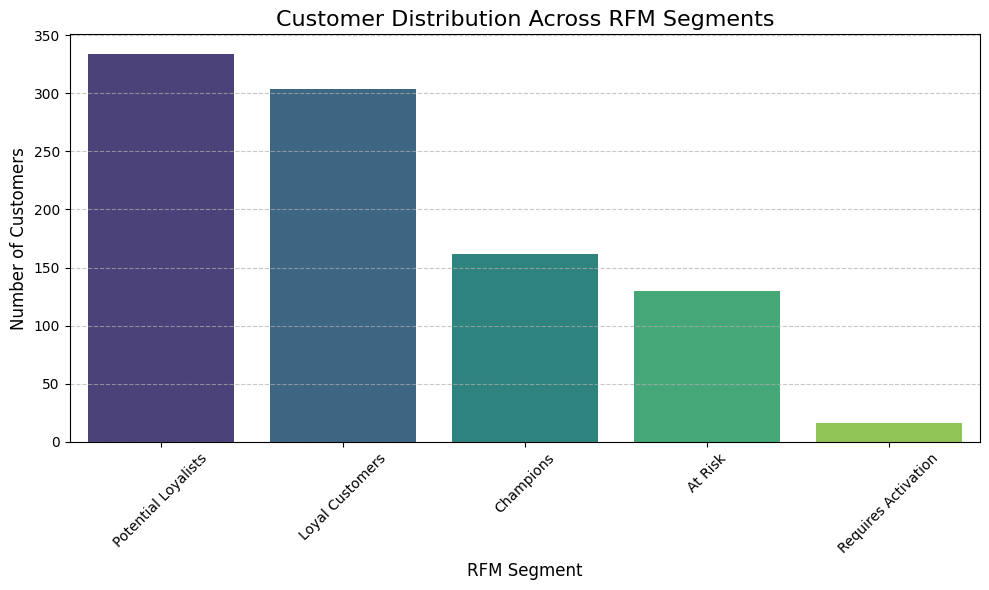

In [46]:
#5.Customer Distribution Across Segments: Calculate and visualize the distribution of customers across different RFM segments.
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the distribution of customers across segments
segment_counts = rfm_df['Customer_Segment'].value_counts().reset_index()
segment_counts.columns = ['Customer_Segment', 'Count']

# Display the raw counts as a table
print("Customer Counts per Segment:")
display(segment_counts)

# Visualize the distribution using a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Customer_Segment', y='Count', data=segment_counts, palette='viridis')

# Add labels and title
plt.title('Customer Distribution Across RFM Segments', fontsize=16)
plt.xlabel('RFM Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add grid lines behind the bars
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()


Revenue Contribution per Segment:


,Customer_Segment,Total_Revenue
2,Loyal Customers,184719.62
3,Potential Loyalists,143807.24
1,Champions,142296.46
0,At Risk,40604.72
4,Requires Activation,2249.77


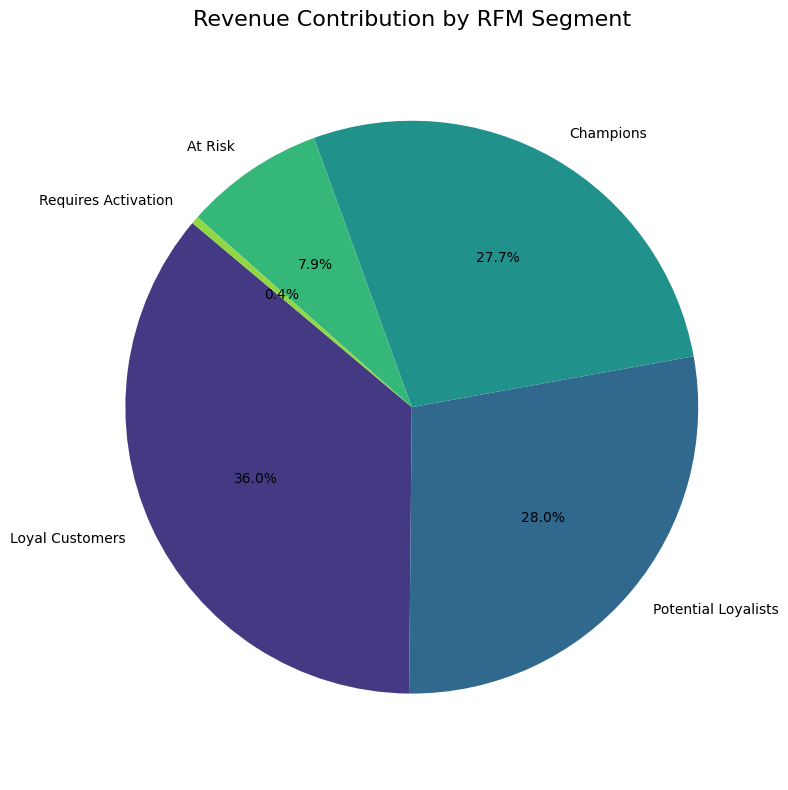

In [47]:
#6.Revenue Contribution by Segment: Determine and visualize the total revenue contribution of each RFM segment.
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total revenue (Monetary sum) by segment
revenue_by_segment = rfm_df.groupby('Customer_Segment')['Monetary'].sum().reset_index()
revenue_by_segment.columns = ['Customer_Segment', 'Total_Revenue']

# Sort the values from highest to lowest revenue
revenue_by_segment = revenue_by_segment.sort_values(by='Total_Revenue', ascending=False)

# Display the raw totals as a table
print("Revenue Contribution per Segment:")
display(revenue_by_segment)

# Visualize the revenue contribution using a pie chart
plt.figure(figsize=(8, 8))
plt.pie(revenue_by_segment['Total_Revenue'],
        labels=revenue_by_segment['Customer_Segment'],
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('viridis', len(revenue_by_segment)))

# Add title and ensure the pie chart is perfectly circular
plt.title('Revenue Contribution by RFM Segment', fontsize=16)
plt.axis('equal')
plt.tight_layout()
plt.show()

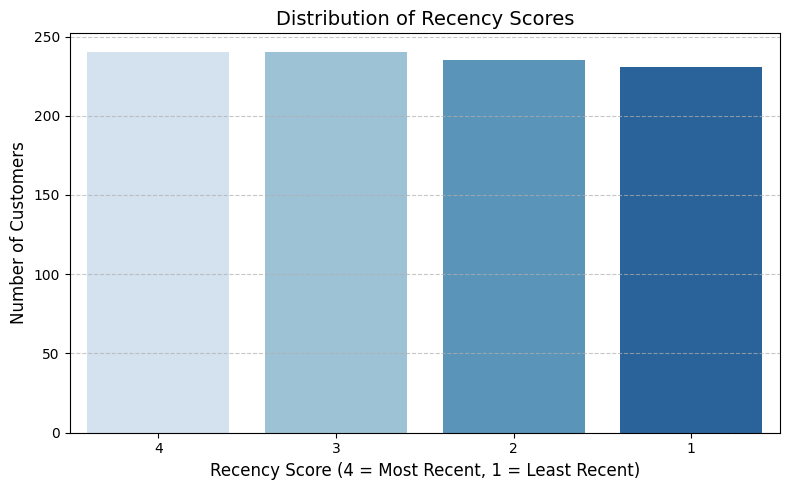

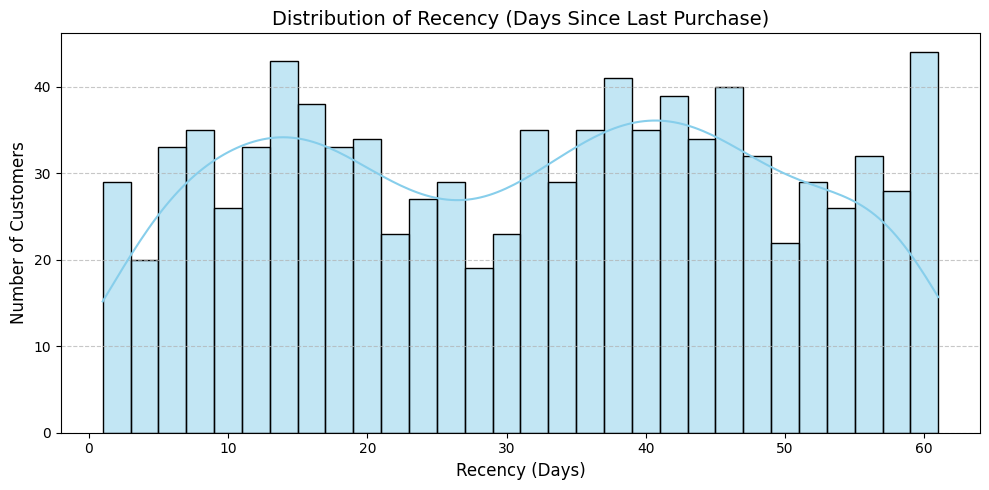

In [48]:
#7.Recency Distribution: Visualize the distribution of recency scores among the customers.
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualize the distribution of Recency Scores (1-4)
plt.figure(figsize=(8, 5))
# Setting hue='R_Score' and legend=False avoids the seaborn deprecation warning
sns.countplot(x='R_Score', data=rfm_df, hue='R_Score', palette='Blues', legend=False)
plt.title('Distribution of Recency Scores', fontsize=14)
plt.xlabel('Recency Score (4 = Most Recent, 1 = Least Recent)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Visualize the distribution of actual Recency (Days)
plt.figure(figsize=(10, 5))
sns.histplot(rfm_df['Recency'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Recency (Days Since Last Purchase)', fontsize=14)
plt.xlabel('Recency (Days)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

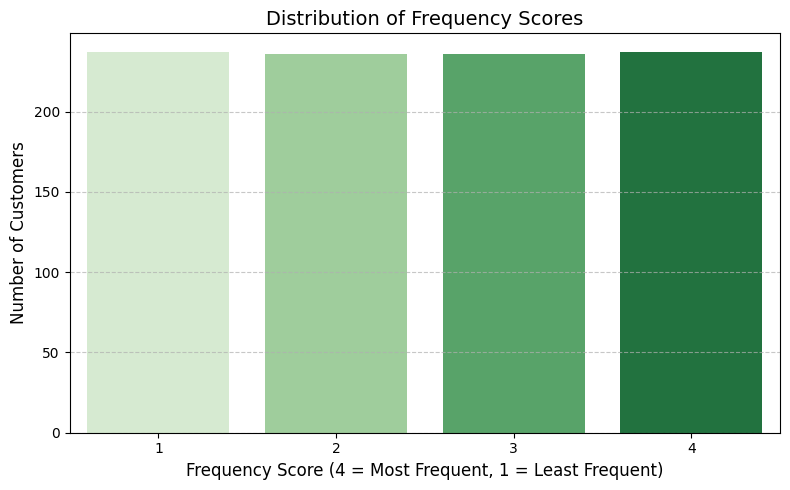

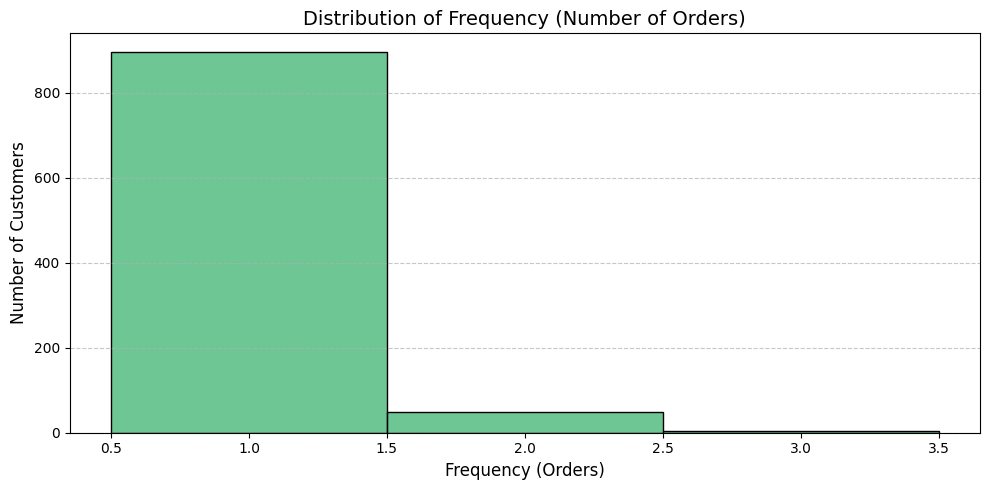

In [49]:
#8.Frequency Distribution: Visualize the distribution of frequency scores among the customers.
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualize the distribution of Frequency Scores (1-4)
plt.figure(figsize=(8, 5))
sns.countplot(x='F_Score', data=rfm_df, hue='F_Score', palette='Greens', legend=False)
plt.title('Distribution of Frequency Scores', fontsize=14)
plt.xlabel('Frequency Score (4 = Most Frequent, 1 = Least Frequent)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Visualize the distribution of actual Frequency (Number of Orders)
plt.figure(figsize=(10, 5))
# Using discrete=True since frequency is a count of orders
sns.histplot(rfm_df['Frequency'], discrete=True, color='mediumseagreen')
plt.title('Distribution of Frequency (Number of Orders)', fontsize=14)
plt.xlabel('Frequency (Orders)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

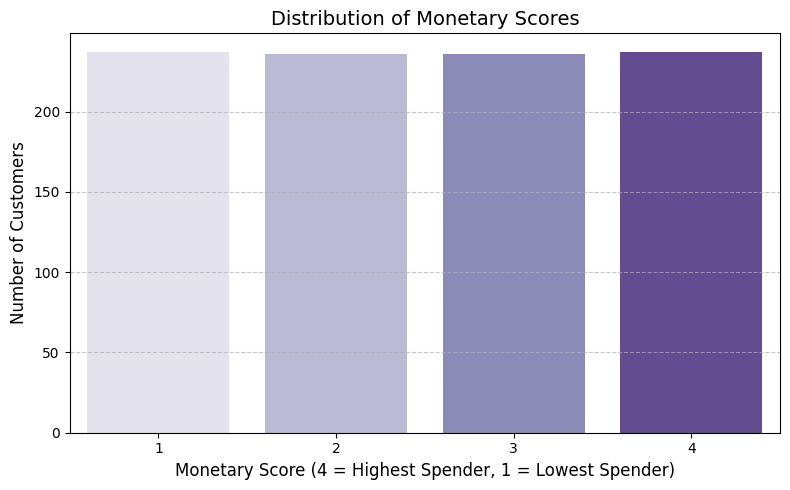

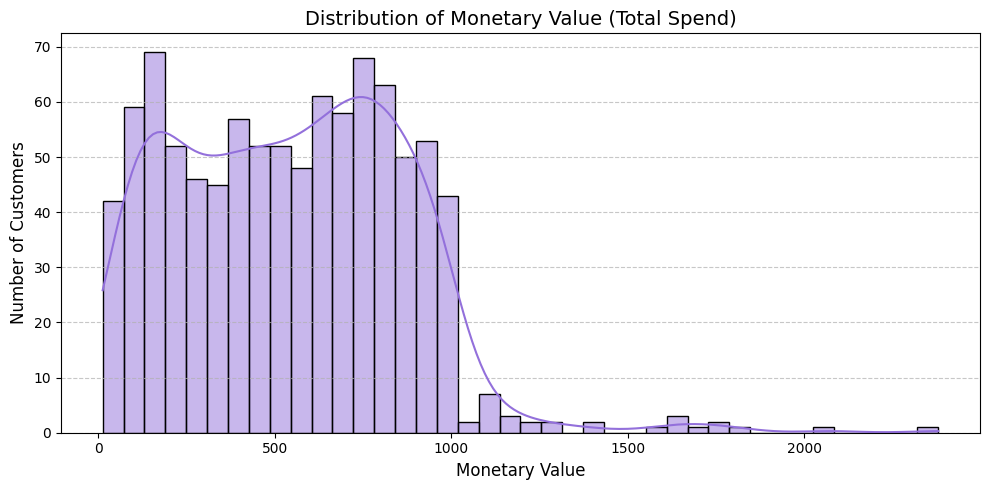

In [50]:
#9.Monetary Value Distribution: Visualize the distribution of monetary values among the customers.
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualize the distribution of Monetary Scores (1-4)
plt.figure(figsize=(8, 5))
# Setting hue='M_Score' and legend=False avoids the seaborn deprecation warning
sns.countplot(x='M_Score', data=rfm_df, hue='M_Score', palette='Purples', legend=False)
plt.title('Distribution of Monetary Scores', fontsize=14)
plt.xlabel('Monetary Score (4 = Highest Spender, 1 = Lowest Spender)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Visualize the distribution of actual Monetary Value (Total Spend)
plt.figure(figsize=(10, 5))
sns.histplot(rfm_df['Monetary'], bins=40, kde=True, color='mediumpurple')
plt.title('Distribution of Monetary Value (Total Spend)', fontsize=14)
plt.xlabel('Monetary Value', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top 10 RFM Segments by Customer Count:


,RFM_Segment,Customer_Count
0,244,25
1,314,21
2,432,21
3,444,20
4,234,20
5,433,20
6,421,20
7,344,20
8,231,20
9,133,20


/tmp/ipykernel_1263/461464754.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RFM_Segment', y='Customer_Count', data=top_rfm_segments.head(10), palette='muted')


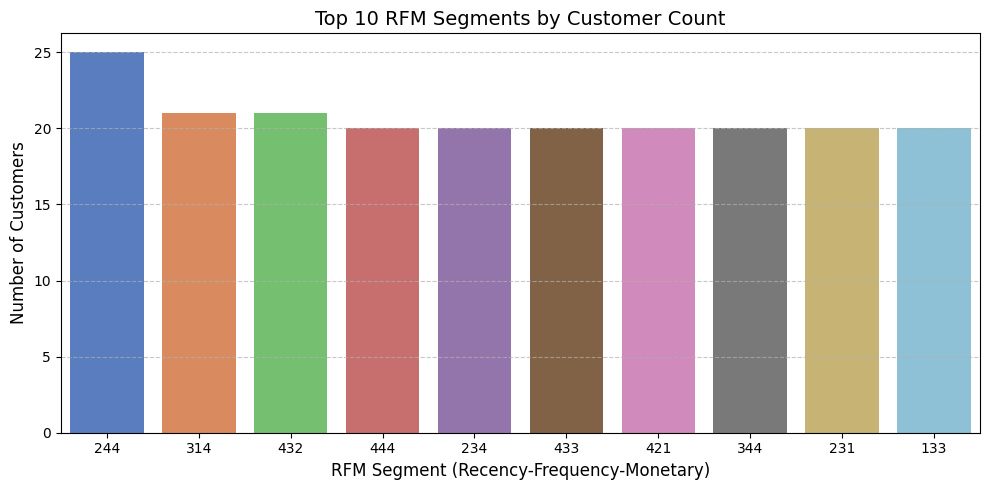

In [51]:
#10.Top Segments by Customer Count: Find the RFM segments with the highest number of customers.
# Count the number of customers in each specific 3-digit RFM Segment
top_rfm_segments = rfm_df['RFM_Segment'].value_counts().reset_index()
top_rfm_segments.columns = ['RFM_Segment', 'Customer_Count']

# Display the top 10 RFM segments with the most customers
print("Top 10 RFM Segments by Customer Count:")
display(top_rfm_segments.head(10))

# Optional: Visualize the top 10 RFM Segments
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(x='RFM_Segment', y='Customer_Count', data=top_rfm_segments.head(10), palette='muted')
plt.title('Top 10 RFM Segments by Customer Count', fontsize=14)
plt.xlabel('RFM Segment (Recency-Frequency-Monetary)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [52]:
## ---------------Subjective Questions ----------------------------

In [53]:
#1.How would you identify segments with low RFM scores indicating potential churn and what targeted interventions would you implement to retain these customers?
# 1. Filter for segments with low RFM scores indicating potential churn
churn_segments = ['At Risk', 'Requires Activation']
churn_risk_df = rfm_df[rfm_df['Customer_Segment'].isin(churn_segments)]

# Display summary statistics for these at-risk customers
print("Summary of Churn-Risk Segments:")
display(churn_risk_df.groupby('Customer_Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(2))

# 2. Merge back with the main df to see what products these customers were buying
churn_products = df[df['CustomerID'].isin(churn_risk_df['CustomerID'])]
top_churn_products = churn_products['ProductInformation'].value_counts().head()

print("\nTop Products purchased by At-Risk/Requires Activation customers:")
display(top_churn_products)

Summary of Churn-Risk Segments:


,Recency,Frequency,Monetary
Customer_Segment,,,
At Risk,46.35,1.0,312.34
Requires Activation,54.56,1.0,140.61



Top Products purchased by At-Risk/Requires Activation customers:


,count
ProductInformation,
Product C,47
Product D,36
Product B,32
Product A,31


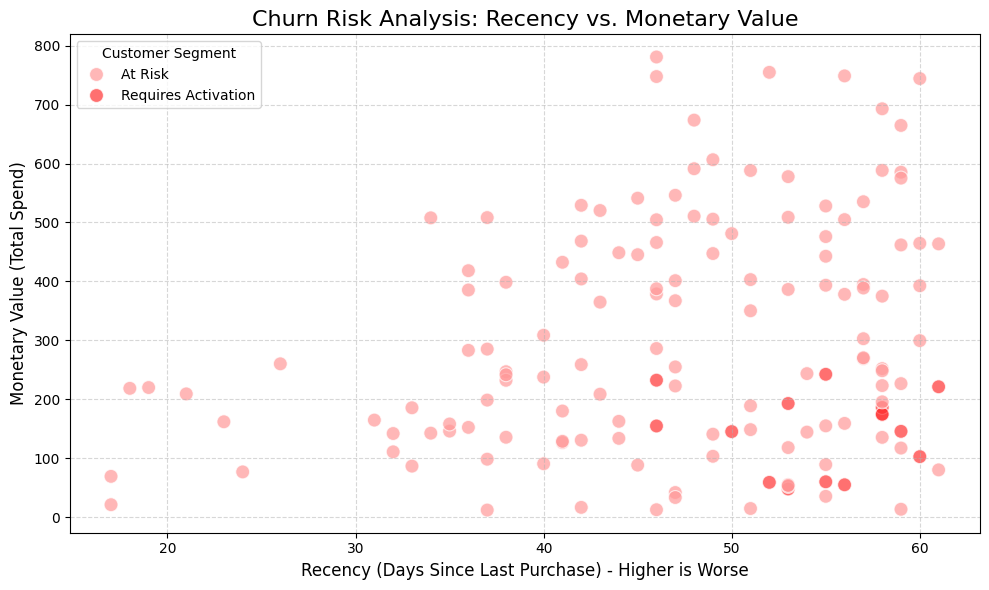

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# Create a scatter plot to show the relationship between Recency and Monetary value for churning segments
sns.scatterplot(
    data=churn_risk_df,
    x='Recency',
    y='Monetary',
    hue='Customer_Segment',
    palette=['#ff9999', '#ff3333'], # Red hues to indicate risk
    s=100,
    alpha=0.7
)

plt.title('Churn Risk Analysis: Recency vs. Monetary Value', fontsize=16)
plt.xlabel('Recency (Days Since Last Purchase) - Higher is Worse', fontsize=12)
plt.ylabel('Monetary Value (Total Spend)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Customer Segment')
plt.tight_layout()
plt.show()

In [55]:
#2.What marketing strategies would you design for each RFM segment? Focus on exclusivity and premium offers for high-value segments and use discounts and promotions for low-value segments.
# 1. Define the marketing strategies for each segment based on value
strategies = {
    'Champions': 'VIP Exclusive Offers & Early Access',
    'Loyal Customers': 'Premium Loyalty Rewards',
    'Potential Loyalists': 'Bundle Deals & Tier Progression',
    'At Risk': 'Targeted Win-Back Discounts (15-20%)',
    'Requires Activation': 'Aggressive Clearance Discounts (30%+)'
}

# 2. Apply strategies to create a new column in the dataframe
rfm_df['Marketing_Strategy'] = rfm_df['Customer_Segment'].map(strategies)

# 3. Aggregate to see how many customers get each strategy
strategy_counts = rfm_df['Marketing_Strategy'].value_counts().reset_index()
strategy_counts.columns = ['Marketing_Strategy', 'Customer_Count']

print("Marketing Strategies by Customer Count:")
display(strategy_counts)

Marketing Strategies by Customer Count:


,Marketing_Strategy,Customer_Count
0,Bundle Deals & Tier Progression,334
1,Premium Loyalty Rewards,304
2,VIP Exclusive Offers & Early Access,162
3,Targeted Win-Back Discounts (15-20%),130
4,Aggressive Clearance Discounts (30%+),16


/tmp/ipykernel_1263/1394308756.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


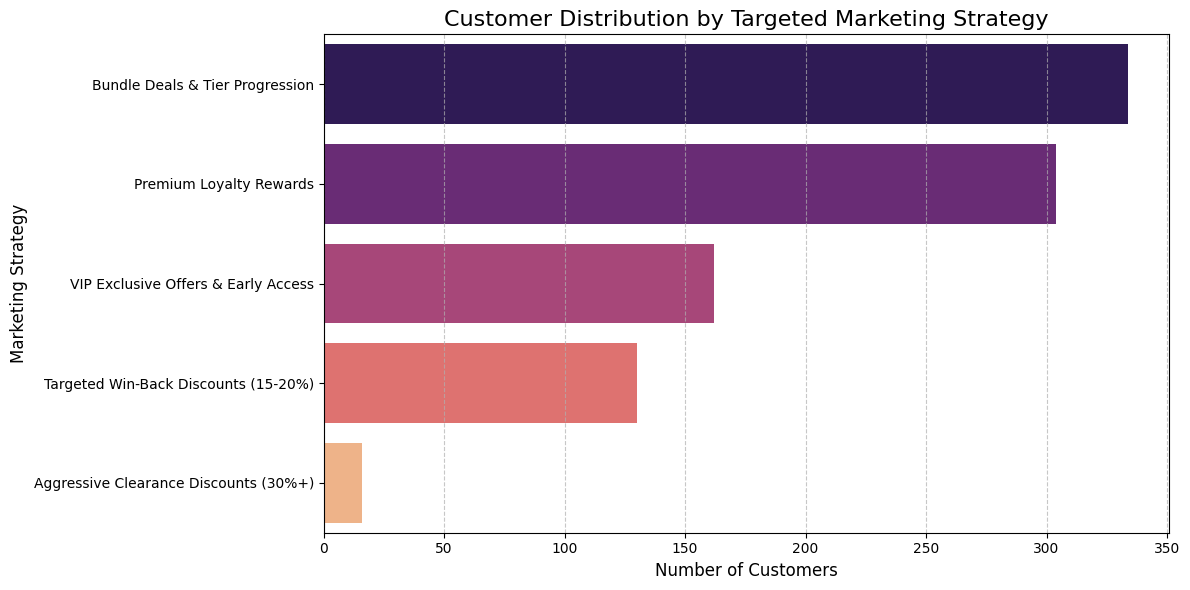

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
# Horizontal bar chart for better readability of strategy labels
sns.countplot(
    y='Marketing_Strategy',
    data=rfm_df,
    order=rfm_df['Marketing_Strategy'].value_counts().index,
    palette='magma' # Using a premium color palette
)

plt.title('Customer Distribution by Targeted Marketing Strategy', fontsize=16)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Marketing Strategy', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [57]:
#3.Based on product preferences in each segment, how would you inform product development to enhance features of top-performing products and address gaps in the product line?
# 1. Merge the main dataset with the RFM segments to link products to customer value
segment_products = pd.merge(df, rfm_df[['CustomerID', 'Customer_Segment']], on='CustomerID', how='inner')

# 2. Create a pivot table to see product purchase counts by segment
product_segment_matrix = pd.crosstab(
    segment_products['Customer_Segment'],
    segment_products['ProductInformation']
)

# Reorder the index logically from highest to lowest value for better readability
ordered_segments = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Requires Activation']
product_segment_matrix = product_segment_matrix.reindex(ordered_segments)

print("Product Purchase Frequency by Customer Segment:")
display(product_segment_matrix)

Product Purchase Frequency by Customer Segment:


ProductInformation,Product A,Product B,Product C,Product D
Customer_Segment,,,,
Champions,43,53,63,49
Loyal Customers,69,84,90,68
Potential Loyalists,82,76,77,100
At Risk,27,29,40,34
Requires Activation,4,3,7,2


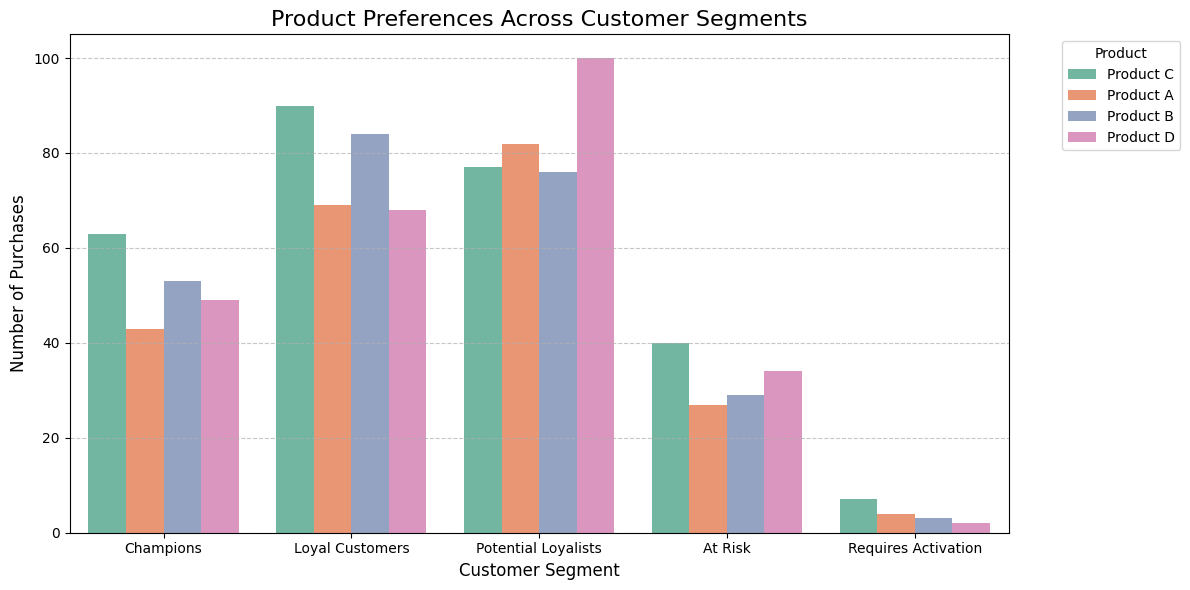

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Create a grouped bar chart to compare product popularity per segment
sns.countplot(
    data=segment_products,
    x='Customer_Segment',
    hue='ProductInformation',
    order=['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Requires Activation'],
    palette='Set2'
)

plt.title('Product Preferences Across Customer Segments', fontsize=16)
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Number of Purchases', fontsize=12)

# Move the legend outside the plot area
plt.legend(title='Product', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [59]:
#4.How would you leverage geographic data to create targeted marketing campaigns for regions with high-value customers and regions with low engagement?
# 1. Extract unique customer locations and merge with RFM data
customer_locations = df[['CustomerID', 'Location']].drop_duplicates()
geo_rfm = pd.merge(rfm_df, customer_locations, on='CustomerID', how='inner')

# 2. Calculate Total Revenue by Location
revenue_by_loc = geo_rfm.groupby('Location')['Monetary'].sum().sort_values(ascending=False).reset_index()
print("Total Revenue by Location:")
display(revenue_by_loc.head())

# 3. Create a matrix of Customer Segments by Location
geo_segments = pd.crosstab(geo_rfm['Location'], geo_rfm['Customer_Segment'])

# Reorder columns logically for the output
ordered_cols = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Requires Activation']
geo_segments = geo_segments.reindex(columns=ordered_cols)

print("\nCustomer Segments by Location:")
display(geo_segments)

Total Revenue by Location:


,Location,Monetary
0,Tokyo,151052.31
1,New York,144197.14
2,London,140394.05
3,Paris,121326.18



Customer Segments by Location:


Customer_Segment,Champions,Loyal Customers,Potential Loyalists,At Risk,Requires Activation
Location,,,,,
London,52,77,82,27,6
New York,53,79,79,30,3
Paris,36,72,84,35,1
Tokyo,54,82,90,38,6


/tmp/ipykernel_1263/3332723128.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Location', y='Monetary', data=revenue_by_loc, palette='viridis', ax=axes[0])


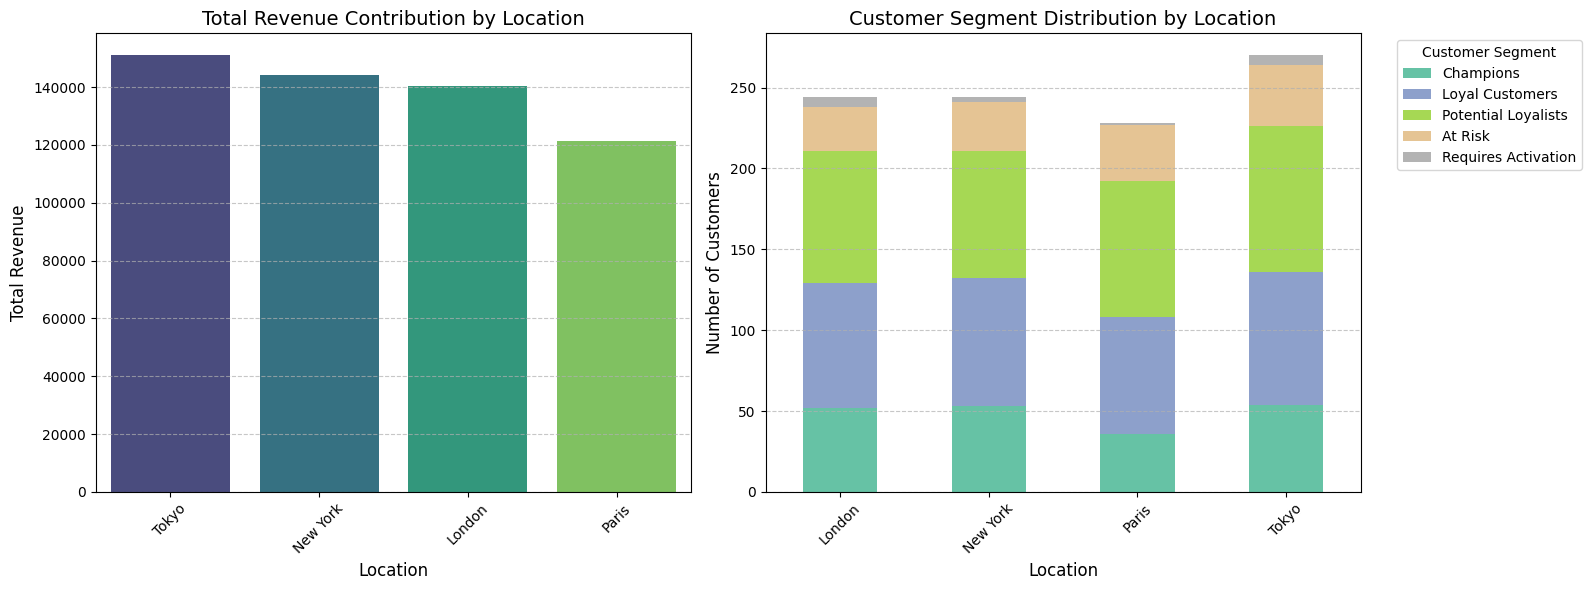

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Revenue by Location
sns.barplot(x='Location', y='Monetary', data=revenue_by_loc, palette='viridis', ax=axes[0])
axes[0].set_title('Total Revenue Contribution by Location', fontsize=14)
axes[0].set_xlabel('Location', fontsize=12)
axes[0].set_ylabel('Total Revenue', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Segment Distribution by Location (Stacked Bar Chart)
geo_segments.plot(kind='bar', stacked=True, colormap='Set2', ax=axes[1])
axes[1].set_title('Customer Segment Distribution by Location', fontsize=14)
axes[1].set_xlabel('Location', fontsize=12)
axes[1].set_ylabel('Number of Customers', fontsize=12)
axes[1].legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [61]:
#5.How would you develop seasonal marketing campaigns based on the seasonal trends observed in different RFM segments to capitalize on peak purchasing times?


In [62]:
# 1. Merge main df with RFM segments and extract the Month
df_seasonal = pd.merge(df, rfm_df[['CustomerID', 'Customer_Segment']], on='CustomerID', how='inner')
df_seasonal['Month'] = df_seasonal['PurchaseDate'].dt.month_name()

# 2. Calculate Total Revenue by Segment and Month
seasonal_revenue = df_seasonal.groupby(['Customer_Segment', 'Month'])['TransactionAmount'].sum().reset_index()

# 3. Ensure the months are ordered chronologically (not alphabetically)
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
seasonal_revenue['Month'] = pd.Categorical(seasonal_revenue['Month'], categories=months_order, ordered=True)
seasonal_revenue = seasonal_revenue.sort_values(['Customer_Segment', 'Month'])

# 4. Pivot the table for a cleaner output view
seasonal_pivot = seasonal_revenue.pivot(index='Customer_Segment', columns='Month', values='TransactionAmount').fillna(0)

print("Monthly Revenue Trends by Customer Segment:")
display(seasonal_pivot)

Monthly Revenue Trends by Customer Segment:


Month,April,May,June
Customer_Segment,,,
At Risk,32620.36,7984.36,0.00
Champions,22630.51,78466.22,41199.73
Loyal Customers,35159.81,123357.43,26202.38
Potential Loyalists,79541.43,57586.14,6679.67
Requires Activation,2249.77,0.00,0.00


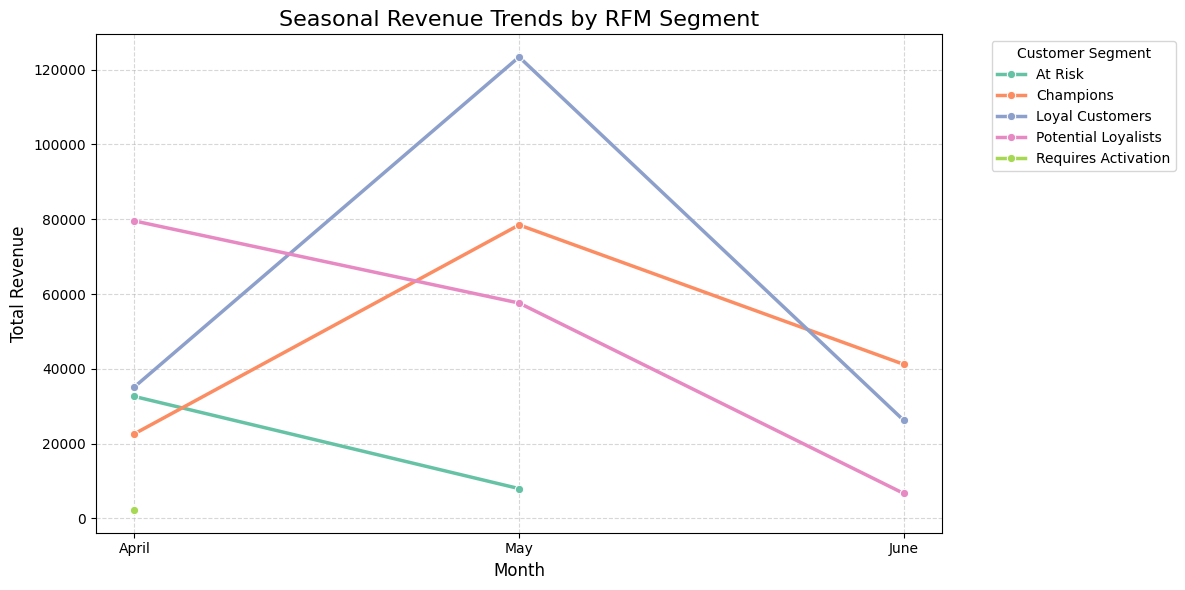

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Create a line plot to show trends over time
sns.lineplot(
    data=seasonal_revenue,
    x='Month',
    y='TransactionAmount',
    hue='Customer_Segment',
    marker='o', # Adds dots to the data points for clarity
    palette='Set2',
    linewidth=2.5
)

plt.title('Seasonal Revenue Trends by RFM Segment', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

# Adjust legend and grid
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [64]:
#6.How would you identify cross-selling opportunities based on purchase data and create bundled offers for customers in different RFM segments?
import pandas as pd
import numpy as np
from itertools import combinations

# 1. Group products by CustomerID to see what each customer buys
customer_products = segment_products.groupby(['CustomerID', 'Customer_Segment'])['ProductInformation'].unique().reset_index()

# Filter for customers who have bought more than 1 distinct product
customer_products['Product_Count'] = customer_products['ProductInformation'].apply(len)
multi_product_customers = customer_products[customer_products['Product_Count'] > 1]

# 2. Calculate Product Co-occurrences
co_occurrences = []
for index, row in multi_product_customers.iterrows():
    segment = row['Customer_Segment']
    prods = sorted(list(row['ProductInformation']))

    for pair in combinations(prods, 2):
        co_occurrences.append({'Customer_Segment': segment, 'Product_A': pair[0], 'Product_B': pair[1]})

co_occurrence_df = pd.DataFrame(co_occurrences)

# 3. Aggregate frequencies by Segment
if not co_occurrence_df.empty:
    bundle_opportunities = co_occurrence_df.groupby(['Customer_Segment', 'Product_A', 'Product_B']).size().reset_index(name='Frequency')
    bundle_opportunities = bundle_opportunities.sort_values(by=['Customer_Segment', 'Frequency'], ascending=[True, False])

    print("Top Bundle Opportunities by Segment:")
    display(bundle_opportunities.groupby('Customer_Segment').head(3))
else:
    print("Not enough multi-product purchases to calculate co-occurrences.")

Top Bundle Opportunities by Segment:


,Customer_Segment,Product_A,Product_B,Frequency
3,Champions,Product B,Product C,9
1,Champions,Product A,Product C,7
4,Champions,Product B,Product D,7
6,Loyal Customers,Product A,Product C,3
7,Loyal Customers,Product A,Product D,1
8,Loyal Customers,Product C,Product D,1
9,Potential Loyalists,Product A,Product B,1


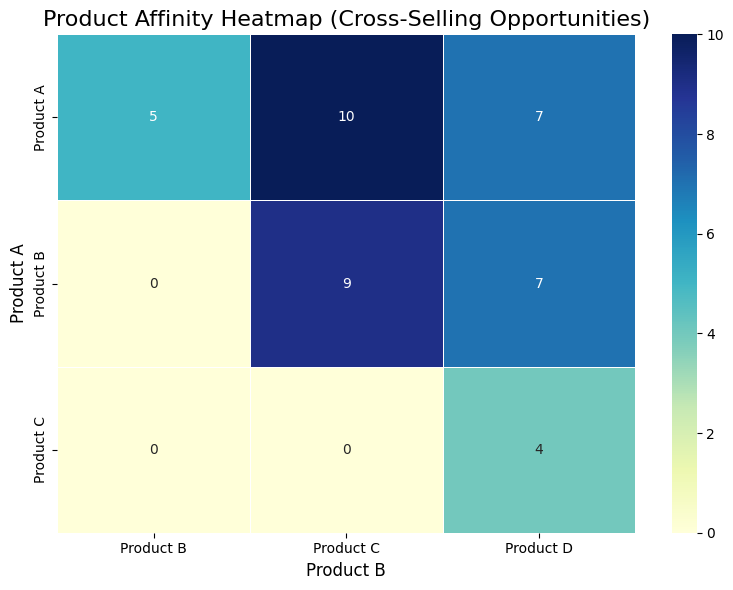

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

if not co_occurrence_df.empty:
    # Create a pivot table for a heatmap of product co-occurrences overall
    heatmap_data = co_occurrence_df.groupby(['Product_A', 'Product_B']).size().unstack(fill_value=0)

    plt.figure(figsize=(8, 6))
    sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='g', linewidths=.5)

    plt.title('Product Affinity Heatmap (Cross-Selling Opportunities)', fontsize=16)
    plt.xlabel('Product B', fontsize=12)
    plt.ylabel('Product A', fontsize=12)
    plt.tight_layout()
    plt.show()

In [68]:
#7.Without direct feedback data, how would you use indirect feedback such as repeat purchases and product returns to refine RFM segmentation and improve customer satisfaction?
# 1. Filter for repeat customers (our proxy for satisfied users)
repeat_customers = df.groupby('CustomerID').filter(lambda x: len(x) > 1).copy()

# 2. Sort by customer and date to find the time between orders
repeat_customers = repeat_customers.sort_values(['CustomerID', 'PurchaseDate'])

# 3. Calculate the days between sequential purchases
repeat_customers['Days_Between_Purchases'] = repeat_customers.groupby('CustomerID')['PurchaseDate'].diff().dt.days

# 4. Merge with RFM segments to see which segments buy fastest
repeat_feedback = pd.merge(repeat_customers, rfm_df[['CustomerID', 'Customer_Segment']], on='CustomerID', how='inner')

# Calculate the average days between purchases per segment
satisfaction_proxy = repeat_feedback.groupby('Customer_Segment')['Days_Between_Purchases'].mean().reset_index()
satisfaction_proxy = satisfaction_proxy.sort_values('Days_Between_Purchases').dropna()

print("Indirect Satisfaction Proxy (Avg Days Between Purchases):")
display(satisfaction_proxy)

Indirect Satisfaction Proxy (Avg Days Between Purchases):


,Customer_Segment,Days_Between_Purchases
2,Potential Loyalists,12.000000
1,Loyal Customers,18.142857
0,Champions,19.695652


In [67]:
#8.How would you analyze the revenue variation by day of the week for different RFM segments to identify patterns and optimize marketing efforts?


,TransactionAmount
DayOfWeek,
Saturday,84535.58
Wednesday,76735.87
Friday,73648.30
Monday,72988.02
Thursday,72934.36
Tuesday,67720.21
Sunday,65115.47


In [70]:
import pandas as pd

# 1. Merge the datasets to link transactions to customer segments
df_day = pd.merge(df, rfm_df[['CustomerID', 'Customer_Segment']], on='CustomerID', how='inner')

# 2. Extract the Day of the Week
df_day['DayOfWeek'] = df_day['PurchaseDate'].dt.day_name()

# 3. Calculate Total Revenue by Segment and Day of the Week
segment_day_revenue = df_day.groupby(['Customer_Segment', 'DayOfWeek'])['TransactionAmount'].sum().reset_index()

# 4. Ensure the days are ordered chronologically for plotting
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
segment_day_revenue['DayOfWeek'] = pd.Categorical(segment_day_revenue['DayOfWeek'], categories=days_order, ordered=True)
segment_day_revenue = segment_day_revenue.sort_values(['Customer_Segment', 'DayOfWeek'])

# 5. Pivot the table for a cleaner output view
day_pivot = segment_day_revenue.pivot(index='Customer_Segment', columns='DayOfWeek', values='TransactionAmount').fillna(0)

print("Revenue Variation by Day of the Week and Segment:")
display(day_pivot)

Revenue Variation by Day of the Week and Segment:


DayOfWeek,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
Customer_Segment,,,,,,,
At Risk,5414.05,4189.31,7633.96,6061.47,6414.85,4975.30,5915.78
Champions,22427.95,16121.14,20074.00,20475.56,21819.18,24789.57,16589.06
Loyal Customers,21395.56,25859.57,30160.62,25146.53,27261.41,31685.03,23210.90
Potential Loyalists,23447.91,21328.90,18081.59,21045.99,17617.71,22940.42,19344.72
Requires Activation,302.55,221.29,785.70,204.81,535.15,145.26,55.01


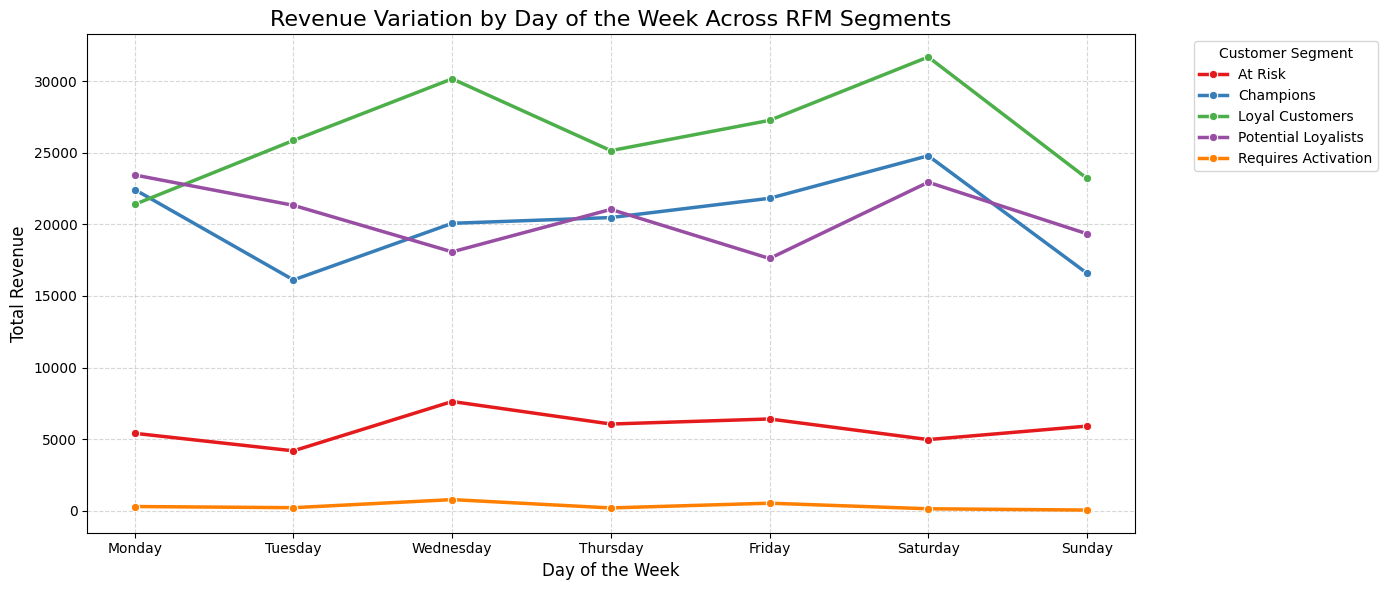

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Create a line plot to show day-of-week trends
sns.lineplot(
    data=segment_day_revenue,
    x='DayOfWeek',
    y='TransactionAmount',
    hue='Customer_Segment',
    marker='o',
    palette='Set1',
    linewidth=2.5
)

plt.title('Revenue Variation by Day of the Week Across RFM Segments', fontsize=16)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)

# Adjust legend and grid
plt.legend(title='Customer Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()